## **MATRIZ CORRELAÇÃO EXEMPLO DO ARTIGO**

In [4]:
import numpy as np
from prody import parseMMCIF, ANM, calcCrossCorr

In [6]:
corrmatrix = np.load("matrizes/holo/4MBP_matriz.npy")

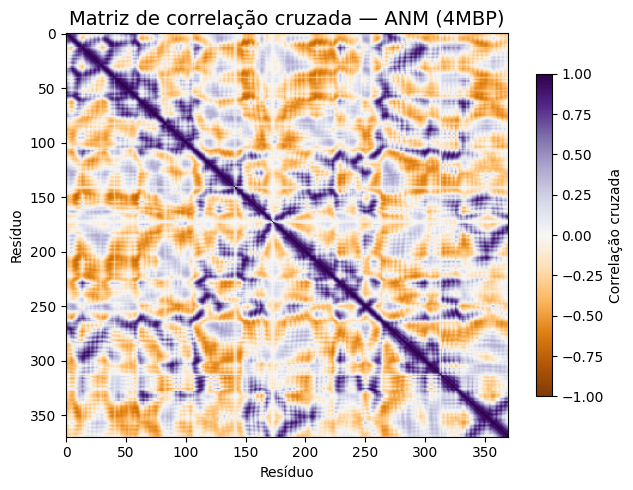

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corrmatrix, cmap='PuOr', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlação cruzada', shrink=0.8)
ax.set_title('Matriz de correlação cruzada — ANM (4MBP)', fontsize=14)
ax.set_xlabel('Resíduo')
ax.set_ylabel('Resíduo')
plt.tight_layout()
plt.show()

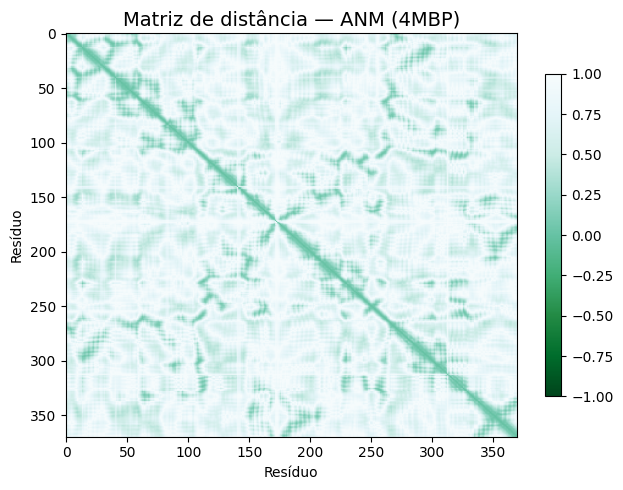

In [8]:
dmatrix = 1 - abs(corrmatrix)

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(dmatrix, cmap='BuGn_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Matriz de distância — ANM (4MBP)', fontsize=14)
ax.set_xlabel('Resíduo')
ax.set_ylabel('Resíduo')
plt.tight_layout()
plt.show()

## **Baixando proteinas com a estrutura MBP**

In [1]:
from rcsbapi.search import AttributeQuery, NestedAttributeQuery

print("Buscando estruturas MBP (UniProt P0AEX9)...")

# Busca usando a estrutura aninhada exigida pela versão mais nova da API
query = NestedAttributeQuery(
    # O nome do banco de dados de referência é o UniProt
    AttributeQuery(
        attribute="rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_name", 
        operator="exact_match", 
        value="UniProt"
    ),
    # O código dentro do UniProt é o da nossa MBP
    AttributeQuery(
        attribute="rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession", 
        operator="exact_match", 
        value="P0AEX9"
    )
)
pdb_ids = list(query())
print("Estruturas encontradas:")
print(len(pdb_ids))

Buscando estruturas MBP (UniProt P0AEX9)...
Estruturas encontradas:
527


In [15]:
from rcsbapi.data import DataQuery
import json

print("\n" + "=" * 70)
print("PASSO 3: OBTENDO INFORMAÇÕES DE LIGANTES (CORRIGIDO)")
print("=" * 70)

print(f"\nProcessando {len(pdb_ids)} estruturas...")

# Usar DataQuery com CAMPOS CORRETOS
try:
    query = DataQuery(
        input_type="entries",
        input_ids=pdb_ids,
        return_data_list=[
            # 1. Conta açúcares/oligossacarídeos (Maltose, Ciclodextrina, etc)
            "rcsb_entry_info.branched_entity_count", 
            
            # 2. Conta pequenos íons ou moléculas simples (Cálcio, Zinco, Sulfato)
            "rcsb_entry_info.nonpolymer_entity_count", 
            
            # 3. Lista o nome exato (sigla) das moléculas pequenas, se houver
            "nonpolymer_entities.rcsb_nonpolymer_entity_container_identifiers.nonpolymer_comp_id",
            
            # 4. Resolução universal (funciona para Raio-X e Cryo-EM)
            "rcsb_entry_info.resolution_combined",
            
            "citation.title",
            "exptl.method"
        ]
    )
    
    resultado = query.exec()
    print(f"\n✓ Dados obtidos com sucesso!")
    
    # Salvar resultado em JSON
    with open("ligantes_raw.json", "w") as f:
        json.dump(resultado, f, indent=2)
        
    print(f"✓ Salvo em: ligantes_raw.json")

except Exception as e:
    print(f"\n✗ Erro: {e}")


PASSO 3: OBTENDO INFORMAÇÕES DE LIGANTES (CORRIGIDO)

Processando 527 estruturas...

✓ Dados obtidos com sucesso!
✓ Salvo em: ligantes_raw.json


In [3]:
import json

print("\n" + "=" * 70)
print("PASSO 4: SEPARANDO APO E HOLO")
print("=" * 70)

# Carrega o JSON perfeito que você acabou de gerar
with open("ligantes_raw.json", "r") as f:
    resultado = json.load(f)

proteinas_holo = []
proteinas_apo = []

# Percorre todas as estruturas do arquivo
for entry in resultado["data"]["entries"]:
    pdb_id = entry["rcsb_id"]
    
    # Pega as informações da proteína
    entry_info = entry.get("rcsb_entry_info", {})
    
    # Se o campo não existir, assumimos 0 (segurança extra)
    branched_count = entry_info.get("branched_entity_count")
    if branched_count is None:
        branched_count = 0
        
    # Lógica de separação: Tem açúcar? É Holo. Não tem? É Apo.
    if branched_count > 0:
        proteinas_holo.append(pdb_id)
    else:
        proteinas_apo.append(pdb_id)

print(f"✓ Total processado: {len(proteinas_holo) + len(proteinas_apo)}")
print(f"➜ Proteínas HOLO (Fechadas): {len(proteinas_holo)}")
print(f"➜ Proteínas APO (Abertas): {len(proteinas_apo)}")


PASSO 4: SEPARANDO APO E HOLO
✓ Total processado: 527
➜ Proteínas HOLO (Fechadas): 281
➜ Proteínas APO (Abertas): 246


In [20]:
import os
import numpy as np
import prody as pr

print("\n" + "=" * 70)
print("PASSO 5 e 6: PIPELINE COMPLETO (DOWNLOAD + ANM + MATRIZES)")
print("=" * 70)

# Configura o ProDy para não poluir muito a tela com mensagens
pr.confProDy(verbosity='info')

def processar_pipeline(lista_ids, categoria):
    # 1. Cria as pastas para os arquivos CIF e para as MATRIZES
    pasta_cif = f"dataset/{categoria}"
    pasta_matriz = f"matrizes/{categoria}"
    
    os.makedirs(pasta_cif, exist_ok=True)
    os.makedirs(pasta_matriz, exist_ok=True)
    
    total = len(lista_ids)
    sucessos = 0
    
    for i, pdb_id in enumerate(lista_ids):
        print(f"\n[{i+1}/{total}] Processando {pdb_id} ({categoria.upper()})...")
        try:
            # 2. O truque do ProDy: Baixa o .cif direto para a pasta correta (se não existir)
            # O fetchPDB retorna o caminho completo do arquivo baixado no seu computador
            caminho_arquivo = pr.fetchPDB(pdb_id, folder=pasta_cif, format='cif')
            
            # 3. Lê o arquivo baixado
            protein = pr.parseMMCIF(caminho_arquivo)
            
            # 4. Seleciona os carbonos alfa
            calphas = protein.select("calpha and chain A")
            
            if calphas is None:
                print(f"  ✗ Erro: Não encontrou carbonos alfa para {pdb_id}.")
                continue
                
            # 5. Matemática do Modelo ANM
            anm = pr.ANM(f'ANM_{pdb_id}')
            anm.buildHessian(calphas)
            anm.calcModes()
            
            # 6. Calcula a matriz de correlação cruzada
            corrmatrix = pr.calcCrossCorr(anm)
            
            # 7. Salva a matriz em formato binário do NumPy (.npy)
            caminho_salvar = os.path.join(pasta_matriz, f"{pdb_id}_matriz.npy")
            np.save(caminho_salvar, corrmatrix)
            
            # Pega o tamanho real da matriz para você acompanhar
            tamanho = corrmatrix.shape[0]
            print(f"  ✓ Concluído! Matriz {tamanho}x{tamanho} salva.")
            sucessos += 1
            
        except Exception as e:
            print(f"  ✗ Falha ao processar {pdb_id}: {e}")
            
    print(f"\nResumo {categoria.upper()}: {sucessos} de {total} matrizes geradas com sucesso.")

# Executando o Pipeline para as listas que você já tinha isolado no Passo 4!
# (Assumindo que as variáveis proteinas_holo e proteinas_apo estejam carregadas)
print("\n➜ INICIANDO LOTE HOLO...")
processar_pipeline(proteinas_holo, "holo")

print("\n➜ INICIANDO LOTE APO...")
processar_pipeline(proteinas_apo, "apo")

@> ProDy is configured: verbosity='info'



PASSO 5 e 6: PIPELINE COMPLETO (DOWNLOAD + ANM + MATRIZES)

➜ INICIANDO LOTE HOLO...

[1/281] Processando 1ANF (HOLO)...


@> Downloading PDB files via FTP failed, trying HTTP.
@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 370x370 salva.

[2/281] Processando 1FQB (HOLO)...


@> Downloading PDB files via FTP failed, trying HTTP.


...

  ✓ Concluído! Matriz 534x534 salva.

[244/246] Processando 9WBG (APO)...


@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 196x196 salva.

[245/246] Processando 9WY8 (APO)...


@> Downloading PDB files via FTP failed, trying HTTP.


  ✓ Concluído! Matriz 495x495 salva.

[246/246] Processando 9XQC (APO)...
  ✓ Concluído! Matriz 233x233 salva.

Resumo APO: 233 de 246 matrizes geradas com sucesso.


In [ ]:
import os

print("\n" + "=" * 70)
print("PASSO 7: AUDITORIA DE ARQUIVOS FALTANTES")
print("=" * 70)

def auditar_pasta(lista_esperada, pasta_arquivos, extensao):
    # 1. Se a pasta não existir ainda, retorna que todos estão faltando
    if not os.path.exists(pasta_arquivos):
        return lista_esperada
        
    # 2. Lista todos os arquivos da pasta
    arquivos_na_pasta = os.listdir(pasta_arquivos)
    
    # 3. Pega apenas o ID do arquivo (ex: corta o ".cif" ou "_matriz.npy" do nome)
    ids_encontrados = []
    for arquivo in arquivos_na_pasta:
        if arquivo.endswith(extensao):
            # Pega só os 4 primeiros caracteres (o PDB ID)
            pdb_id = arquivo[:4].upper() 
            ids_encontrados.append(pdb_id)
            
    # 4. A Mágica dos Conjuntos: Esperado MINUS Encontrado
    set_esperado = set(lista_esperada)
    set_encontrado = set(ids_encontrados)
    
    ids_faltantes = list(set_esperado - set_encontrado)
    
    return ids_faltantes

# --- AUDITORIA DOS ARQUIVOS .CIF (DOWNLOAD) ---
print("\n➜ Verificando Downloads (.cif.gz):")
cif_faltantes_holo = auditar_pasta(proteinas_holo, "dataset/holo", ".cif.gz")
cif_faltantes_apo = auditar_pasta(proteinas_apo, "dataset/apo", ".cif.gz")

print(f"HOLO Faltantes ({len(cif_faltantes_holo)}): {cif_faltantes_holo}")
print(f"APO Faltantes ({len(cif_faltantes_apo)}): {cif_faltantes_apo}")

# --- AUDITORIA DAS MATRIZES (.NPY) ---
print("\n➜ Verificando Matrizes Geradas (.npy):")
matriz_faltantes_holo = auditar_pasta(proteinas_holo, "matrizes/holo", ".npy")
matriz_faltantes_apo = auditar_pasta(proteinas_apo, "matrizes/apo", ".npy")

print(f"Matrizes HOLO Faltantes ({len(matriz_faltantes_holo)}): {matriz_faltantes_holo}")
print(f"Matrizes APO Faltantes ({len(matriz_faltantes_apo)}): {matriz_faltantes_apo}")


PASSO 7: AUDITORIA DE ARQUIVOS FALTANTES

➜ Verificando Downloads (.cif):
HOLO Faltantes (0): []
APO Faltantes (0): []

➜ Verificando Matrizes Geradas (.npy):
Matrizes HOLO Faltantes (2): ['6DKS', '1T0K']
Matrizes APO Faltantes (13): ['8GKH', '9CF3', '9CET', '9CEZ', '9CEV', '2V93', '9PGN', '9CEU', '9CEW', '9CEY', '9CES', '8VG0', '9CEX']


In [17]:
import os
import numpy as np
import prody as pr

print("\n" + "=" * 70)
print("PASSO 8: RESGATE DAS MATRIZES FALTANTES")
print("=" * 70)

pr.confProDy(verbosity='none') # Oculta os avisos padrões para vermos só nossos prints

def resgatar_matrizes(lista_faltantes, categoria):
    if not lista_faltantes:
        print(f"➜ Nenhuma matriz faltando na categoria {categoria.upper()}! Tudo certo.")
        return

    pasta_cif = f"dataset/{categoria}"
    pasta_matriz = f"matrizes/{categoria}"
    sucessos = 0
    
    print(f"\nIniciando resgate de {len(lista_faltantes)} proteínas ({categoria.upper()})...")

    for pdb_id in lista_faltantes:
        try:
            # 1. Localiza o arquivo que já foi baixado (tenta .cif e .cif.gz)
            caminho_arquivo = os.path.join(pasta_cif, f"{pdb_id}.cif")
            if not os.path.exists(caminho_arquivo):
                caminho_arquivo += ".gz" 
                
            # Se por algum motivo não achar, manda o ProDy baixar rapidinho
            if not os.path.exists(caminho_arquivo):
                caminho_arquivo = pr.fetchPDB(pdb_id, folder=pasta_cif, format='cif')

            # 2. Abre a molécula
            protein = pr.parseMMCIF(caminho_arquivo)
            if protein is None:
                continue

            # 3. ESTRATÉGIA DE RESGATE: Descobre quais cadeias existem
            todos_calphas = protein.select('calpha')
            if todos_calphas is None:
                print(f"  ✗ Erro: Não há carbonos alfa na estrutura {pdb_id}.")
                continue
                
            # Pega as letras únicas de todas as cadeias e ordena (ex: ['B', 'C'])
            cadeias_disponiveis = list(set(todos_calphas.getChids()))
            cadeias_disponiveis.sort()
            
            # Pega a primeira cadeia existente
            cadeia_alvo = cadeias_disponiveis[0]
            
            # 4. Seleciona os resíduos apenas da cadeia encontrada
            calphas = protein.select(f"calpha and chain {cadeia_alvo}")
            tamanho = calphas.numAtoms()
            
            print(f"➜ {pdb_id}: Cadeia A ausente. Usando a cadeia '{cadeia_alvo}' (Tamanho: {tamanho} resíduos).")
            
            # Alerta de Segurança para o seu Machine Learning (esperamos aprox 370 resíduos)
            if tamanho < 340 or tamanho > 400:
                print(f"    ⚠️ AVISO: O tamanho dessa cadeia ({tamanho}) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!")

            # 5. Calcula ANM e gera a matriz de correlação
            anm = pr.ANM(f'ANM_{pdb_id}')
            anm.buildHessian(calphas)
            anm.calcModes()
            
            corrmatrix = pr.calcCrossCorr(anm)
            
            # 6. Salva a matriz
            caminho_salvar = os.path.join(pasta_matriz, f"{pdb_id}_matriz.npy")
            np.save(caminho_salvar, corrmatrix)
            
            print(f"    ✓ Matriz {pdb_id}_matriz.npy gerada com sucesso!")
            sucessos += 1

        except Exception as e:
            print(f"  ✗ Falha ao processar {pdb_id}: {e}")

    print(f"\nResultado final {categoria.upper()}: {sucessos}/{len(lista_faltantes)} recuperadas.")

# Chama a função passando as variáveis de IDs faltantes que você encontrou no passo anterior
# (Certifique-se de que matriz_faltantes_holo e matriz_faltantes_apo estejam na memória)
resgatar_matrizes(matriz_faltantes_holo, "holo")
resgatar_matrizes(matriz_faltantes_apo, "apo")

@> ProDy is configured: verbosity='none'



PASSO 8: RESGATE DAS MATRIZES FALTANTES

Iniciando resgate de 2 proteínas (HOLO)...
➜ 6DKS: Cadeia A ausente. Usando a cadeia 'C' (Tamanho: 417 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (417) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 6DKS_matriz.npy gerada com sucesso!
➜ 1T0K: Cadeia A ausente. Usando a cadeia 'C' (Tamanho: 365 resíduos).
    ✓ Matriz 1T0K_matriz.npy gerada com sucesso!

Resultado final HOLO: 2/2 recuperadas.

Iniciando resgate de 13 proteínas (APO)...
➜ 8GKH: Cadeia A ausente. Usando a cadeia 'B' (Tamanho: 600 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (600) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 8GKH_matriz.npy gerada com sucesso!
➜ 9CF3: Cadeia A ausente. Usando a cadeia 'B' (Tamanho: 162 resíduos).
    ⚠️ AVISO: O tamanho dessa cadeia (162) está muito diferente do padrão MBP (~370). Isso pode quebrar seu ML!
    ✓ Matriz 9CF3_matriz.npy gerada com sucesso!
➜ 9CET: Cadeia 

In [20]:
import os
import numpy as np

print("\n" + "=" * 70)
print("PASSO 9: DIAGNÓSTICO DE SHAPES DAS MATRIZES")
print("=" * 70)

def auditar_dimensoes(categoria, tamanho_esperado=370):
    pasta_matrizes = f"matrizes/{categoria}"
    if not os.path.exists(pasta_matrizes):
        return []
        
    arquivos = [f for f in os.listdir(pasta_matrizes) if f.endswith('.npy')]
    anomalos = []
    
    for arquivo in arquivos:
        caminho_arquivo = os.path.join(pasta_matrizes, arquivo)
        # Carrega a matriz para ler o tamanho
        matriz = np.load(caminho_arquivo)
        tamanho = matriz.shape[0] # Pega o N da matriz NxN
        
        # Se for diferente do esperado, guarda na lista
        if tamanho != tamanho_esperado:
            pdb_id = arquivo[:4] # Pega as 4 primeiras letras (o ID)
            anomalos.append((pdb_id, tamanho))
            
    # Ordena a lista do menor para o maior tamanho para facilitar a leitura
    anomalos.sort(key=lambda x: x[1])
    
    print(f"\n➜ Categoria {categoria.upper()} ({len(arquivos)} matrizes analisadas):")
    if not anomalos:
         print(f"  ✓ Todas as matrizes têm exatos {tamanho_esperado}x{tamanho_esperado}!")
    else:
         print(f"  ⚠️ Encontradas {len(anomalos)} matrizes fora do padrão:")
         for pdb_id, tam in anomalos:
             print(f"      - {pdb_id}: {tam}x{tam}")
             
    return [item[0] for item in anomalos]

# Executa para as duas classes
anomalos_holo = auditar_dimensoes("holo")
anomalos_apo = auditar_dimensoes("apo")

print(f"\nTotal de matrizes que precisarão ser tratadas: {len(anomalos_holo) + len(anomalos_apo)}")


PASSO 9: DIAGNÓSTICO DE SHAPES DAS MATRIZES

➜ Categoria HOLO (281 matrizes analisadas):
  ⚠️ Encontradas 259 matrizes fora do padrão:
      - 8AG0: 165x165
      - 7NZM: 178x178
      - 8JXR: 270x270
      - 4NDZ: 287x287
      - 8G8W: 289x289
      - 3PGF: 358x358
      - 1MDP: 363x363
      - 6OB5: 364x364
      - 1T0K: 365x365
      - 3HST: 365x365
      - 5BJZ: 365x365
      - 6WGZ: 365x365
      - 1N3W: 366x366
      - 1NL5: 366x366
      - 1YTV: 366x366
      - 3SEU: 366x366
      - 5BK2: 367x367
      - 6TZC: 367x367
      - 7JIJ: 367x367
      - 7XMN: 367x367
      - 1IUD: 368x368
      - 1NMU: 368x368
      - 6USM: 368x368
      - 9XKO: 368x368
      - 1LAX: 369x369
      - 3HPI: 369x369
      - 6LF3: 369x369
      - 7JTR: 369x369
      - 7MK7: 369x369
      - 1JVX: 371x371
      - 1JVY: 371x371
      - 1MDQ: 371x371
      - 2R6G: 371x371
      - 3SEY: 371x371
      - 4KI0: 371x371
      - 5MM3: 371x371
      - 3LBS: 372x372
      - 6QUG: 373x373
      - 7MQ6: 373x373
      

In [ ]:
import os
import numpy as np
from collections import defaultdict

print("\n" + "=" * 70)
print("PASSO 10 (MODIFICADO): EXTRAÇÃO DOS IDs ALVO (370x370)")
print("=" * 70)

def coletar_distribuicao_com_ids(categoria):
    pasta = f"matrizes/{categoria}"
    # Cria um dicionário onde o padrão é uma lista vazia
    distribuicao = defaultdict(list)
    
    if not os.path.exists(pasta):
        return distribuicao
        
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.npy')]
    
    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)
        # mmap_mode='r' lê apenas os metadados (muito rápido)
        matriz = np.load(caminho, mmap_mode='r')
        tamanho = matriz.shape[0]
        
        # Pega as 4 primeiras letras do nome do arquivo (ex: "1ANF_matriz.npy" -> "1ANF")
        pdb_id = arquivo[:4].upper()
        
        # Adiciona o ID na lista correspondente àquela dimensão
        distribuicao[tamanho].append(pdb_id)
        
    return distribuicao

# 1. Coleta os dados (agora mapeando os IDs)
dist_holo = coletar_distribuicao_com_ids("holo")
dist_apo = coletar_distribuicao_com_ids("apo")

# 2. Extrai as listas EXATAS para a dimensão alvo de 370
# Se não houver nenhum, retorna uma lista vazia []
ids_perfeitos_holo = dist_holo.get(370, [])
ids_perfeitos_apo = dist_apo.get(370, [])

print(f"\n➜ IDs ALVO - HOLO ({len(ids_perfeitos_holo)} matrizes):")
print(ids_perfeitos_holo)

print(f"\n➜ IDs ALVO - APO ({len(ids_perfeitos_apo)} matrizes):")
print(ids_perfeitos_apo)

# Bônus: Mostrar rapidamente se existem de outros tamanhos
outros_tamanhos = set(dist_holo.keys()).union(set(dist_apo.keys())) - {370}
print(f"\n(Existem outros {len(outros_tamanhos)} tamanhos anômalos que foram ignorados com sucesso).")


PASSO 10 (MODIFICADO): EXTRAÇÃO DOS IDs ALVO (370x370)

➜ IDs ALVO - HOLO / FECHADAS (22 matrizes):
['1ANF', '1DMB', '1EZ9', '1FQA', '1FQB', '1FQC', '1FQD', '1JW5', '1MPD', '3MBP', '3PUZ', '3PV0', '3SER', '3SES', '3SET', '3SEV', '3SEW', '3SEX', '4KHZ', '4MBP', '5E24', '8YBE']

➜ IDs ALVO - APO / ABERTAS (20 matrizes):
['1EZO', '1EZP', '1JW4', '1LLS', '1MPB', '1MPC', '1OMP', '1ZIU', '1ZJL', '1ZKB', '1ZMG', '2D21', '2H25', '2KLF', '2MV0', '2N44', '2N45', '3KJT', '7Z7H', '8C8F']

(Existem outros 255 tamanhos anômalos que foram ignorados com sucesso).


## **APLICAÇÃO DO MACHING LEARNING**

In [1]:
import os
import numpy as np
import pandas as pd
import gudhi
from gudhi.representations import Landscape
from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from itertools import combinations
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:

warnings.filterwarnings("ignore")

# =============================================================================
# 1. IDENTIFICAÇÃO DAS 14 PROTEÍNAS DO ARTIGO BASE
# =============================================================================

ids_fechadas = ['1ANF', '1FQC', '1FQD', '1MPD', '3HPI', '3MBP', '4MBP']
ids_abertas  = ['1EZ9', '1FQA', '1FQB', '1JW4', '1JW5', '1LLS', '1OMP']

# =============================================================================
# 2. FUNÇÕES AUXILIARES
# =============================================================================
def limpar_cache_novas(ids_novas, grau):
    """
    Apaga o cache apenas das proteínas novas (não rotuladas).
    Use antes de um novo treinamento com parâmetros diferentes.
    """
    removidos = 0
    for pdb_id in ids_novas:
        cache_path = f"Dados/matrizes/cache/{pdb_id}_paisagem_grau{grau}.npy"
        if os.path.exists(cache_path):
            os.remove(cache_path)
            removidos += 1
    print(f"✓ Cache limpo: {removidos} arquivo(s) removido(s).")

def encontrar_matriz(pdb_id):
    """Retorna (caminho, tipo) onde tipo é 'holo' ou 'apo'"""
    for pasta in ['holo', 'apo']:
        caminho = f"Dados/matrizes/{pasta}/{pdb_id}_matriz.npy"
        if os.path.exists(caminho):
            return caminho, pasta
    return None, None


def corr_to_dist(corr):

    D = 1.0 - np.abs(corr)
    # Garante simetria e diagonal zero (pode haver ruído numérico)
    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2.0

    # Verifica se há valores negativos
    if np.any(D < 0):
        print("Aviso: valores negativos na matriz de distância. Aplicando clip.")
        D = np.clip(D, 0.0, None)
    return D


def calcular_paisagem_de_persistencia(D, grau=1, n_camadas=None, n_pontos=50,
                                       t_min=0.0, t_max=1.0):
    
    # Constrói o complexo de Vietoris-Rips usa t_max diretamente como max_edge_length.
    # O artigo trabalha com D em [0,1] e a filtração também em [0,1].
    # O código original usava I = 2*J erroneamente (herança da versão
    # para nuvens de pontos, onde raio = diâmetro/2).

    rips = gudhi.RipsComplex(distance_matrix=D, max_edge_length=t_max)
    st = rips.create_simplex_tree(max_dimension=grau + 1)
    st.persistence(persistence_dim_max=True, homology_coeff_field=2)

    # Intervalos de persistência para o grau solicitado
    intervalos = st.persistence_intervals_in_dimension(grau)

    # Remove intervalos com morte = infinito (substituindo por t_max)
    intervalos_finitos = []
    for (nasc, morte) in intervalos:
        if np.isinf(morte):
            morte = t_max
        intervalos_finitos.append([nasc, morte])

    if len(intervalos_finitos) == 0:
        # Sem características nesse grau: vetor de zeros
        k = n_camadas if n_camadas is not None else 1
        return np.zeros(k * n_pontos)

    intervalos_finitos = np.array(intervalos_finitos)

    # Calcula a paisagem de persistência via gudhi.representations
    # n_jobs=-1 usa todos os núcleos disponíveis
    # NOTA: o número de camadas k varia por grau e proteína.
    # Fixamos n_camadas para garantir vetores de tamanho uniforme.
    if n_camadas is None:
        # Heurística baseada no artigo: grau 0 → 370, grau 1 → 73, grau 2 → 78
        n_camadas_padrao = {0: 370, 1: 73, 2: 78}
        n_camadas = n_camadas_padrao.get(grau, 50)

    landscape = Landscape(
        num_landscapes=n_camadas,
        resolution=n_pontos,
        sample_range=[t_min, t_max]
    )

    # A API do gudhi.representations espera lista de diagramas
    # Cada diagrama é array (n_pontos, 2) com (nascimento, morte)
    vetor = landscape.fit_transform([intervalos_finitos])
    # Retorna array 1D de tamanho n_camadas * n_pontos
    return vetor.flatten()


# =============================================================================
# 3. EXTRAÇÃO DE FEATURES (PAISAGEM DE PERSISTÊNCIA)
# =============================================================================

# Configuração do intervalo de filtração — artigo usa [0, ~0.7]
T_MIN   = 0.0
T_MAX   = 0.7
N_PONTOS = 50  # artigo usa 50 valores discretos

# Número de camadas por grau (artigo, p.14)
N_CAMADAS = {0: 370, 1: 73, 2: 78}

# Grau de homologia de interesse principal
GRAU_PRINCIPAL = 1

print("=" * 70)
print(f"EXTRAÇÃO DE PAISAGENS DE PERSISTÊNCIA — GRAU {GRAU_PRINCIPAL}")
print("=" * 70)

X_features = []
y_labels   = []
ids_usados = []

os.makedirs("Dados/matrizes/cache", exist_ok=True)

for pdb_id, label in (
    [(pid, 1) for pid in ids_fechadas] +
    [(pid, 0) for pid in ids_abertas]
):
    caminho, _= encontrar_matriz(pdb_id)

    if caminho is None:
        print(f"{pdb_id}: matriz não encontrada. Pulando.")
        continue

    cache_path = f"Dados/matrizes/cache/{pdb_id}_paisagem_grau{GRAU_PRINCIPAL}.npy"

    try:
        if os.path.exists(cache_path):
            paisagem = np.load(cache_path)
            print(f" ↩ {pdb_id} carregada do cache.")
        else:
            corr = np.load(caminho)
            D    = corr_to_dist(corr)
            paisagem = calcular_paisagem_de_persistencia(
                D,
                grau=GRAU_PRINCIPAL,
                n_camadas=N_CAMADAS[GRAU_PRINCIPAL],
                n_pontos=N_PONTOS,
                t_min=T_MIN,
                t_max=T_MAX
            )
            np.save(cache_path, paisagem)
            print(f" ✓ {pdb_id} calculada e salva no cache.")

    except Exception as e:
        print(f" ✗ {pdb_id}: erro ao processar — {e}. Pulando.")
        continue

    X_features.append(paisagem)
    y_labels.append(label)
    ids_usados.append(pdb_id)


X_features = np.array(X_features)
y_labels   = np.array(y_labels)

if X_features.ndim != 2 or len(X_features) == 0:
    raise RuntimeError("Nenhuma proteína foi processada com sucesso. Verifique os caminhos das matrizes.")

print(f"\nDataset: {X_features.shape[0]} amostras × {X_features.shape[1]} features")
print(f"(= {N_CAMADAS[GRAU_PRINCIPAL]} camadas × {N_PONTOS} pontos por camada)")

# =============================================================================
# 4. TREINAMENTO COM LEAVE-ONE-OUT + PCA + SVM
#    Seguindo o artigo: PCA com 3 componentes após padronização,
#    SVM com kernel linear.
#
#    IMPORTANTE: StandardScaler e PCA são ajustados APENAS nos dados de
#    treino de cada fold. Isso evita data leakage — um erro comum quando
#    o scaler é ajustado no conjunto completo antes do LOO.
# =============================================================================

print("\n" + "=" * 70)
print("VALIDAÇÃO LEAVE-ONE-OUT: PCA (3 comp.) + SVM linear")
print("=" * 70)

loo = LeaveOneOut()

# Pipeline garante que StandardScaler + PCA são re-ajustados a cada fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # padronização (artigo: "standardized data")
    ('pca',    PCA(n_components=3)),    # artigo usa os 3 primeiros CPs
    ('svm',    svm.SVC(kernel='linear', C=1.0))
])

previsoes  = []
corretas   = []
resultados = []

for train_idx, test_idx in loo.split(X_features):
    X_train, X_test = X_features[train_idx], X_features[test_idx]
    y_train, y_test = y_labels[train_idx],   y_labels[test_idx]

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)[0]

    correto = (pred == y_test[0])
    previsoes.append(pred)
    corretas.append(correto)

    pdb_id    = ids_usados[test_idx[0]]
    real      = "Fechada" if y_test[0] == 1 else "Aberta"
    previsto  = "Fechada" if pred == 1 else "Aberta"
    simbolo   = "✓" if correto else "✗"
    resultados.append(f"  {simbolo} {pdb_id}: real={real}, previsto={previsto}")

for r in resultados:
    print(r)

n_acertos = sum(corretas)
acuracia  = n_acertos / len(y_labels)

print(f"\n{'=' * 30}")
print(f"RESULTADO DO MODELO SVM")
print(f"{'=' * 30}")
print(f"Acurácia (LOO): {acuracia * 100:.2f}%")
print(f"Acertos: {n_acertos} de {len(y_labels)}")

# Variância explicada pelo PCA (treinado no conjunto completo, só para inspeção)
scaler_final = StandardScaler().fit(X_features)
X_scaled     = scaler_final.transform(X_features)
pca_inspeção = PCA(n_components=3).fit(X_scaled)
var_explicada = np.cumsum(pca_inspeção.explained_variance_ratio_)
print(f"\nVariância explicada pelos 3 CPs: {var_explicada[-1]*100:.2f}%")
print(f"  CP1: {pca_inspeção.explained_variance_ratio_[0]*100:.2f}%")
print(f"  CP2: {pca_inspeção.explained_variance_ratio_[1]*100:.2f}%")
print(f"  CP3: {pca_inspeção.explained_variance_ratio_[2]*100:.2f}%")
print("  (artigo reporta ~52.50% para grau 1)")

# =============================================================================
# 5. MODELO FINAL — TREINADO COM AS 14 PROTEÍNAS
#    Pronto para classificar as 28 proteínas restantes
# =============================================================================

print("\n" + "=" * 70)
print("TREINAMENTO DO MODELO FINAL (todas as 14 proteínas)")
print("=" * 70)

pipeline.fit(X_features, y_labels)
print("✓ Modelo final treinado e pronto para classificar novas proteínas.")

# =============================================================================
# 6. CLASSIFICAÇÃO DAS NOVAS PROTEÍNAS (28 não rotuladas)
# =============================================================================

print("\n" + "=" * 70)
print("CLASSIFICAÇÃO DAS NOVAS PROTEÍNAS")
print("=" * 70)

#Lista de proteinas não analisadas
# Proteínas alvo com dimensão correta (370×370 ou 369×369)
ids_holo_alvo = ['1ANF', '1DMB', '1EZ9', '1FQA', '1FQB', '1FQC', '1FQD',
                 '1JW5', '1MPD', '3MBP', '3PUZ', '3PV0', '3SER', '3SES',
                 '3SET', '3SEV', '3SEW', '3SEX', '4KHZ', '4MBP', '5E24', '8YBE']

ids_apo_alvo  = ['1EZO', '1EZP', '1JW4', '1LLS', '1MPB', '1MPC', '1OMP',
                 '1ZIU', '1ZJL', '1ZKB', '1ZMG', '2D21', '2H25', '2KLF',
                 '2MV0', '2N44', '2N45', '3KJT', '7Z7H', '8C8F']

ids_conhecidos = set(ids_fechadas + ids_abertas)
ids_novas = [pid for pid in ids_holo_alvo + ids_apo_alvo
             if pid not in ids_conhecidos]

# Para usar quando quiser resetar só as novas:
# limpar_cache_novas(ids_novas, GRAU_PRINCIPAL)

if not ids_novas:
    print("  → Nenhuma proteína nova encontrada nas pastas.")
else:
    ids_novas_processadas = []
    previsoes_novas = []
    tipos_novas = [] 

    for pdb_id in ids_novas:
        caminho, tipo = encontrar_matriz(pdb_id)

        if caminho is None:
            print(f" {pdb_id}: matriz não encontrada.")
            continue

        cache_path = f"Dados/matrizes/cache/{pdb_id}_paisagem_grau{GRAU_PRINCIPAL}.npy"

        if os.path.exists(cache_path):
            paisagem = np.load(cache_path)
            print(f"  ↩ {pdb_id} carregada do cache.", end=" ")
        else:
            corr     = np.load(caminho)
            D        = corr_to_dist(corr)
            paisagem = calcular_paisagem_de_persistencia(
                D,
                grau=GRAU_PRINCIPAL,
                n_camadas=N_CAMADAS[GRAU_PRINCIPAL],
                n_pontos=N_PONTOS,
                t_min=T_MIN,
                t_max=T_MAX
            )
            np.save(cache_path, paisagem)
            print(f"  ✓ {pdb_id} calculada e salva.", end=" ")

        pred       = pipeline.predict([paisagem])[0]
        ids_novas_processadas.append(pdb_id)    
        previsoes_novas.append(pred)
        tipos_novas.append(tipo)    
        nome_label = "FECHADA" if pred == 1 else "ABERTA"
        print(f"→ {nome_label}")
    
    # Dicionário de resultados acessível diretamente
    resultados_classificacao = {}
    df_resultados = pd.DataFrame([
        {
            'PDB_ID':        pid,
            'Conformacao':   tipo.upper(),
            'Classificacao': "FECHADA" if pred == 1 else "ABERTA"
        }
        for pid, pred, tipo in zip(ids_novas_processadas, previsoes_novas, tipos_novas)
    ])

    for _, row in df_resultados.iterrows():
        resultados_classificacao[row['PDB_ID']] = row['Classificacao']

    print("\n", df_resultados.to_string(index=False))
    df_resultados.to_csv("resultados_classificacao.csv", index=False)
    print("\n✓ Resultados salvos em resultados_classificacao.csv")

EXTRAÇÃO DE PAISAGENS DE PERSISTÊNCIA — GRAU 1
 ↩ 1ANF carregada do cache.
 ↩ 1FQC carregada do cache.
 ↩ 1FQD carregada do cache.
 ↩ 1MPD carregada do cache.
 ↩ 3HPI carregada do cache.
 ↩ 3MBP carregada do cache.
 ↩ 4MBP carregada do cache.
 ↩ 1EZ9 carregada do cache.
 ↩ 1FQA carregada do cache.
 ↩ 1FQB carregada do cache.
 ↩ 1JW4 carregada do cache.
 ↩ 1JW5 carregada do cache.
 ↩ 1LLS carregada do cache.
 ↩ 1OMP carregada do cache.

Dataset: 14 amostras × 3650 features
(= 73 camadas × 50 pontos por camada)

VALIDAÇÃO LEAVE-ONE-OUT: PCA (3 comp.) + SVM linear
  ✓ 1ANF: real=Fechada, previsto=Fechada
  ✓ 1FQC: real=Fechada, previsto=Fechada
  ✓ 1FQD: real=Fechada, previsto=Fechada
  ✓ 1MPD: real=Fechada, previsto=Fechada
  ✓ 3HPI: real=Fechada, previsto=Fechada
  ✓ 3MBP: real=Fechada, previsto=Fechada
  ✓ 4MBP: real=Fechada, previsto=Fechada
  ✓ 1EZ9: real=Aberta, previsto=Aberta
  ✓ 1FQA: real=Aberta, previsto=Aberta
  ✓ 1FQB: real=Aberta, previsto=Aberta
  ✓ 1JW4: real=Aberta, previ

In [ ]:
def area_paisagem(vetor_paisagem, t_max=T_MAX, n_pontos=N_PONTOS):
    """
    Calcula a área total sob todas as camadas da paisagem (Eq. 2),
    aproximada por soma de Riemann sobre a discretização em n_pontos.
    """
    dt = t_max / n_pontos
    return vetor_paisagem.sum() * dt
 
X_areas = np.array([area_paisagem(v) for v in X_features])
 
holo_mask = (y_labels == 1)
apo_mask  = (y_labels == 0)
 
X_holo = X_areas[holo_mask]
X_apo  = X_areas[apo_mask]
 
n1, n2 = len(X_holo), len(X_apo)
print(f"n_Holo = {n1}, n_Apo = {n2}")
print(f"Média X_Holo = {X_holo.mean():.6f}")
print(f"Média X_Apo  = {X_apo.mean():.6f}")
 
T_obs = abs(X_holo.mean() - X_apo.mean())
print(f"T_obs = |X̄_Holo - X̄_Apo| = {T_obs:.6f}")
 

todos_valores = np.concatenate([X_holo, X_apo])
N = len(todos_valores)
assert N == n1 + n2
 
contagem = 0
total = 0
for idx_grupo1 in combinations(range(N), n1):
    idx_grupo1 = set(idx_grupo1)
    g1 = np.array([todos_valores[i] for i in range(N) if i in idx_grupo1])
    g2 = np.array([todos_valores[i] for i in range(N) if i not in idx_grupo1])
    T_i = abs(g1.mean() - g2.mean())
    if T_i >= T_obs:
        contagem += 1
    total += 1
 
p_valor = contagem / total
print(f"\nTotal de permutações M = {total}  (deve ser C(14,7) = 3432)")
print(f"Permutações com T_i >= T_obs: {contagem}")
print(f"Valor-p empírico = {p_valor:.6f}")
 
alpha = 0.05
if p_valor < alpha:
    print(f"\np = {p_valor:.4f} < α = 0.05  →  REJEITA H0")
    print("Evidência estatística de que a média da variável topológica X")
    print("difere significativamente entre as conformações Apo e Holo.")
else:
    print(f"\np = {p_valor:.4f} >= α = 0.05  →  NÃO REJEITA H0")
    print("Não há evidência suficiente, nesta amostra, de diferença entre médias.")
 

resultado_permutacao = {
    "n_holo": int(n1),
    "n_apo": int(n2),
    "media_holo": float(X_holo.mean()),
    "media_apo": float(X_apo.mean()),
    "T_obs": float(T_obs),
    "M_permutacoes": int(total),
    "p_valor": float(p_valor),
}
print("\nDicionário para citar na Seção 8:")
print(resultado_permutacao)

n_Holo = 7, n_Apo = 7
Média X_Holo = 0.269778
Média X_Apo  = 0.290403
T_obs = |X̄_Holo - X̄_Apo| = 0.020625

Total de permutações M = 3432  (deve ser C(14,7) = 3432)
Permutações com T_i >= T_obs: 2
Valor-p empírico = 0.000583

p = 0.0006 < α = 0.05  →  REJEITA H0
Evidência estatística de que a média da variável topológica X
difere significativamente entre as conformações Apo e Holo.

Dicionário para citar na Seção 8:
{'n_holo': 7, 'n_apo': 7, 'media_holo': 0.26977813398029044, 'media_apo': 0.290403282693339, 'T_obs': 0.020625148713048547, 'M_permutacoes': 3432, 'p_valor': 0.0005827505827505828}


[[-0.01560686 -0.12336453  0.01106544]
 [ 0.00921368 -0.17789373  0.04003095]
 [ 0.08252694 -0.1649343   0.02477839]
 ...
 [-0.10663238 -0.1685115   0.14561051]
 [-0.05719435 -0.11750989  0.19179806]
 [-0.09258437 -0.09925593  0.16010499]]


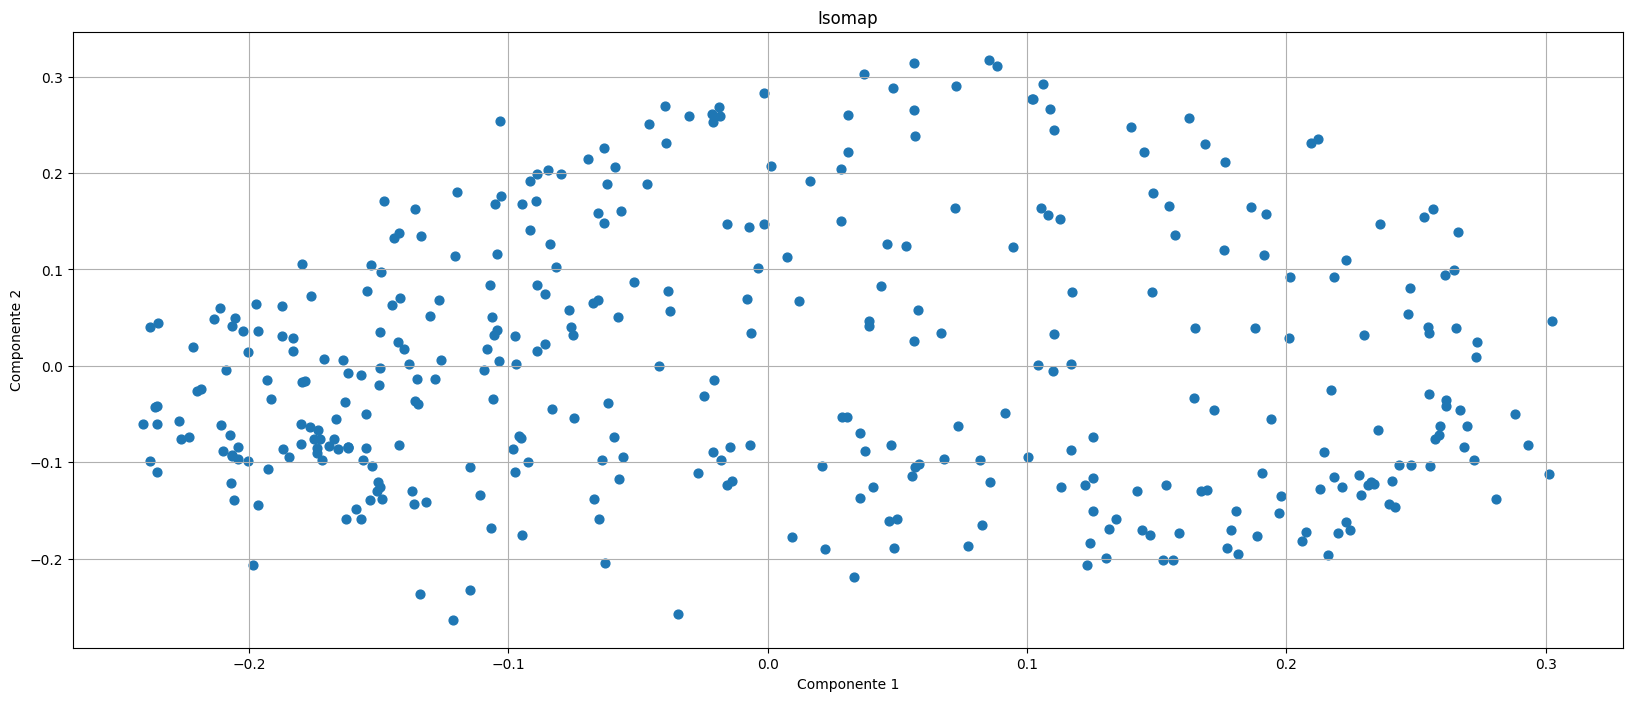

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap


# carregar matriz
D = np.load("Dados/matrizes/apo/1OMP_matriz.npy")


# corrigir negativos
if D.min() < 0:
    D = D - D.min()

np.fill_diagonal(D, 0)

# garantir simetria
D = (D + D.T)/2


# Isomap
iso = Isomap(
    n_neighbors=300,
    n_components=3,
    metric='precomputed'
)

X_iso = iso.fit_transform(D)
plt.figure(figsize=(20,8))

plt.scatter(
    X_iso[:,0],
    X_iso[:,1],
    s=40
)

plt.title("Isomap")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.grid(True)
print(X_iso)
plt.show()

In [4]:
scaler_treinado = pipeline.named_steps['scaler']
pca_treinado = pipeline.named_steps['pca']
svm_treinado = pipeline.named_steps['svm']

# 2. Carregando as Paisagens das 29 proteínas (do Cache)
X_novas = []
ids_plot = []
tipos_plot = []
previsoes_plot = []

# Usamos as listas que o seu Bloco 6 já gerou
for pid, tipo, pred in zip(ids_novas_processadas, tipos_novas, previsoes_novas):
    cache_path = f"Dados/matrizes/cache/{pid}_paisagem_grau{GRAU_PRINCIPAL}.npy"
    if os.path.exists(cache_path):
        paisagem = np.load(cache_path)
        X_novas.append(paisagem)
        ids_plot.append(pid)
        tipos_plot.append(tipo.upper())
        previsoes_plot.append(pred)

X_novas = np.array(X_novas)

# 3. Projetando os dados cegos no espaço 3D do modelo
X_novas_scaled = scaler_treinado.transform(X_novas)
X_novas_pca = pca_treinado.transform(X_novas_scaled)

# 4. Matemática do Hiperplano (Fronteira de Decisão)
w = svm_treinado.coef_[0]
bias = svm_treinado.intercept_[0]

# Criando a "lona" do hiperplano com base nos limites das novas proteínas
xx, yy = np.meshgrid(
    np.linspace(X_novas_pca[:, 0].min() - 5, X_novas_pca[:, 0].max() + 5, 20),
    np.linspace(X_novas_pca[:, 1].min() - 5, X_novas_pca[:, 1].max() + 5, 20)
)
zz = (-w[0] * xx - w[1] * yy - bias) / w[2]

# =============================================================================
# 5. PLOTAGEM DO GRÁFICO
# =============================================================================
%matplotlib qt
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Desenhando o Hiperplano separador
ax.plot_surface(xx, yy, zz, color='gray', alpha=0.3, rstride=100, cstride=100)

# Plotando as 29 proteínas
for i in range(len(ids_plot)):
    x_val, y_val, z_val = X_novas_pca[i]
    tipo = tipos_plot[i]  # 'HOLO' ou 'APO'
    pred = previsoes_plot[i] # 1 ou 0
    pid = ids_plot[i]
    
    # Cor = O que a Máquina previu (Vermelho=Fechada, Azul=Aberta)
    cor = 'red' if pred == 1 else 'blue'
    
    # Formato = O que a Química diz (Bolinha=Holo, Triângulo=Apo)
    marcador = 'o' if tipo == 'HOLO' else '^'
    
    ax.scatter(x_val, y_val, z_val, color=cor, marker=marcador, s=120, edgecolors='black', depthshade=True)
    
    # Destacando com texto as Anomalias Biológicas
    if pid in ['2N45', '1DMB']:
        # Coloca o nome da proteína flutuando um pouco acima do ponto
        ax.text(x_val, y_val, z_val + 1.5, f"{pid}*", color='black', fontsize=12, fontweight='bold')

# Criando legendas personalizadas para explicar cores e formas
import matplotlib.lines as mlines
legendas = [
    mlines.Line2D([], [], color='red', marker='s', linestyle='None', markersize=10, label='IA Previu: FECHADA'),
    mlines.Line2D([], [], color='blue', marker='s', linestyle='None', markersize=10, label='IA Previu: ABERTA'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='Química Real: HOLO'),
    mlines.Line2D([], [], color='gray', marker='^', linestyle='None', markersize=10, label='Química Real: APO')
]

ax.set_title("Inferência Topológica das Proteínas Desconhecidas", fontsize=15, fontweight='bold')
ax.set_xlabel(f'CP 1 ({pca_treinado.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'CP 2 ({pca_treinado.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'CP 3 ({pca_treinado.explained_variance_ratio_[2]*100:.1f}%)')

ax.legend(handles=legendas, loc='upper left', bbox_to_anchor=(0.0, 1.0))
ax.view_init(elev=20, azim=60)

plt.tight_layout()
plt.savefig("inferencia_28_novas_tcc.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
%matplotlib inline

In [6]:
import pandas as pd

distancias_brutas = pipeline.decision_function(X_novas)

dados_distancia = []

for pid, tipo, dist in zip(ids_plot, tipos_plot, distancias_brutas):
    # O valor absoluto é a distância física até a fronteira de decisão
    confianca = abs(dist)
    
    # Valores > 0 indicam a classe 1 (Fechada), valores < 0 indicam a classe 0 (Aberta)
    previsao = "FECHADA" if dist > 0 else "ABERTA"
    
    # Classificação analítica do estado conformacional
    if pid in ['2N45', '1DMB']:
        alerta = "ANOMALIA BIOLÓGICA"
    elif confianca < 0.5:
        alerta = " FRONTEIRA (Estado Intermédio)"
    else:
        alerta = "✓ Conformação Rígida/Segura"
        
    dados_distancia.append({
        'PDB_ID': pid,
        'Química Real': tipo,
        'Previsão IA': previsao,
        'Distância Absoluta': round(confianca, 4),
        'Status': alerta
    })

# Cria um DataFrame e ordena para que as proteínas mais coladas ao plano apareçam no topo
df_distancias = pd.DataFrame(dados_distancia)
df_distancias = df_distancias.sort_values(by='Distância Absoluta')

print(df_distancias.to_string(index=False))

# Estatísticas de Prova
proteinas_comuns = df_distancias[~df_distancias['PDB_ID'].isin(['2N45', '1DMB'])]
media_comuns = proteinas_comuns['Distância Absoluta'].mean()

dist_2n45 = df_distancias[df_distancias['PDB_ID'] == '2N45']['Distância Absoluta'].values[0]
dist_1dmb = df_distancias[df_distancias['PDB_ID'] == '1DMB']['Distância Absoluta'].values[0]

print("\n" + "-" * 70)
print("RESUMO DA PROVA ESTATÍSTICA:")
print(f"➜ Distância Média das Proteínas Comuns: {media_comuns:.4f}")
print(f"➜ Distância da 2N45 (Apo Fechada):      {dist_2n45:.4f}")
print(f"➜ Distância da 1DMB (Holo Aberta):      {dist_1dmb:.4f}")
print("-" * 70)

PDB_ID Química Real Previsão IA  Distância Absoluta                      Status
  2N45          APO     FECHADA              0.1985          ANOMALIA BIOLÓGICA
  2D21          APO      ABERTA              0.6017 ✓ Conformação Rígida/Segura
  8C8F          APO      ABERTA              0.7306 ✓ Conformação Rígida/Segura
  1DMB         HOLO      ABERTA              0.7676          ANOMALIA BIOLÓGICA
  1MPB          APO      ABERTA              0.8794 ✓ Conformação Rígida/Segura
  1ZIU          APO      ABERTA              0.8820 ✓ Conformação Rígida/Segura
  2H25          APO      ABERTA              0.9732 ✓ Conformação Rígida/Segura
  5E24         HOLO     FECHADA              0.9863 ✓ Conformação Rígida/Segura
  3SER         HOLO     FECHADA              1.0395 ✓ Conformação Rígida/Segura
  3SET         HOLO     FECHADA              1.1151 ✓ Conformação Rígida/Segura
  3KJT          APO      ABERTA              1.1209 ✓ Conformação Rígida/Segura
  2MV0          APO      ABERTA         

In [8]:
import pandas as pd
import numpy as np
import gzip
import os
import warnings
from itertools import product
from Bio.PDB import Superimposer
from Bio.PDB.MMCIFParser import MMCIFParser
warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURAÇÃO — GRUPOS DE REFERÊNCIA COMPLETOS (14 estruturas gabarito)
# =============================================================================

REFS_FECHADAS = ['1ANF', '1FQC', '1FQD', '1MPD', '3HPI', '3MBP', '4MBP']
REFS_ABERTAS  = ['1EZ9', '1FQA', '1FQB', '1JW4', '1JW5', '1LLS', '1OMP']

# =============================================================================
# FUNÇÕES AUXILIARES (idênticas ao script original)
# =============================================================================

def carregar_estrutura(pdb_id):
    parser_cif = MMCIFParser(QUIET=True)
    for pasta in ['holo', 'apo']:
        caminho = f"Dados/dataset/{pasta}/{pdb_id.lower()}.cif.gz"
        if os.path.exists(caminho):
            with gzip.open(caminho, 'rt') as f:
                return parser_cif.get_structure(pdb_id, f)
    raise FileNotFoundError(
        f"Estrutura {pdb_id} não encontrada em dataset/apo/ nem dataset/holo/"
    )


def extrair_ca(estrutura, chain_id=None):
    model = estrutura[0]
    chain = list(model.get_chains())[0] if chain_id is None else model[chain_id]
    ca_atoms = []
    for residuo in chain.get_residues():
        if residuo.get_id()[0] != ' ':
            continue
        if 'CA' in residuo:
            ca_atoms.append(residuo['CA'])
    return ca_atoms


def calcular_rmsd(estrutura_ref, estrutura_alvo, chain_ref=None, chain_alvo=None):
    ca_ref  = extrair_ca(estrutura_ref,  chain_ref)
    ca_alvo = extrair_ca(estrutura_alvo, chain_alvo)
    n = min(len(ca_ref), len(ca_alvo))
    ca_ref, ca_alvo = ca_ref[:n], ca_alvo[:n]
    sup = Superimposer()
    sup.set_atoms(ca_ref, ca_alvo)
    sup.apply(estrutura_alvo.get_atoms())
    return round(sup.rms, 4), n


# =============================================================================
# CARREGA ESTRUTURAS DE REFERÊNCIA (as 14 gabarito, uma única vez)
# =============================================================================

print("Carregando as 14 estruturas de referência...")
estruturas_fechadas = {}
estruturas_abertas  = {}

for pid in REFS_FECHADAS:
    estruturas_fechadas[pid] = carregar_estrutura(pid)
    print(f"  ✓ {pid} (fechada) carregada.")

for pid in REFS_ABERTAS:
    estruturas_abertas[pid] = carregar_estrutura(pid)
    print(f"  ✓ {pid} (aberta) carregada.")

df = pd.read_csv("resultados_classificacao.csv")

# =============================================================================
# ABORDAGEM 1 — RMSD MÉDIO AO GRUPO (resultado principal recomendado)
# =============================================================================

print("\n[Abordagem 1] Calculando RMSD médio contra os 7 grupos...\n")

media_fechada_col, std_fechada_col = [], []
media_aberta_col,  std_aberta_col  = [], []
conclusao_media_col = []

for _, row in df.iterrows():
    pdb_id = row['PDB_ID']
    try:
        estrutura = carregar_estrutura(pdb_id)

        rmsds_fechada = [calcular_rmsd(ref, estrutura)[0]
                          for ref in estruturas_fechadas.values()]
        rmsds_aberta  = [calcular_rmsd(ref, estrutura)[0]
                          for ref in estruturas_abertas.values()]

        media_f, std_f = np.mean(rmsds_fechada), np.std(rmsds_fechada)
        media_a, std_a = np.mean(rmsds_aberta),  np.std(rmsds_aberta)

        conclusao = "FECHADA" if media_f < media_a else "ABERTA"

        media_fechada_col.append(round(media_f, 4))
        std_fechada_col.append(round(std_f, 4))
        media_aberta_col.append(round(media_a, 4))
        std_aberta_col.append(round(std_a, 4))
        conclusao_media_col.append(conclusao)

        print(f"  {pdb_id}: RMSD_médio_fechada={media_f:.4f}±{std_f:.4f} | "
              f"RMSD_médio_aberta={media_a:.4f}±{std_a:.4f} | → {conclusao}")

    except Exception as e:
        print(f"  ✗ {pdb_id}: erro — {e}. Pulando.")
        media_fechada_col.append(None); std_fechada_col.append(None)
        media_aberta_col.append(None);  std_aberta_col.append(None)
        conclusao_media_col.append(None)

df['RMSD_Medio_Fechada'] = media_fechada_col
df['RMSD_Std_Fechada']   = std_fechada_col
df['RMSD_Medio_Aberta']  = media_aberta_col
df['RMSD_Std_Aberta']    = std_aberta_col
df['Conclusao_RMSD_Medio'] = conclusao_media_col
df['Concordancia_Medio'] = df.apply(
    lambda r: 'CONCORDA' if r['Classificacao'] == r['Conclusao_RMSD_Medio']
    else ('DIVERGE' if r['Conclusao_RMSD_Medio'] is not None else 'SEM_DADOS'),
    axis=1
)

df.to_csv("resultados_rmsd_medio.csv", index=False)
print("\n✓ Resultados salvos em resultados_rmsd_medio.csv")

# =============================================================================
# ABORDAGEM 2 — ANÁLISE DE SENSIBILIDADE (49 combinações de pares)
# =============================================================================

print("\n[Abordagem 2] Análise de sensibilidade — 49 pares de referência...\n")

# Pré-carrega TODAS as estruturas alvo uma única vez (evita recarregar 49x)
estruturas_alvo = {}
for pdb_id in df['PDB_ID']:
    try:
        estruturas_alvo[pdb_id] = carregar_estrutura(pdb_id)
    except Exception:
        pass

resultados_sensibilidade = {pdb_id: [] for pdb_id in estruturas_alvo}

for ref_f_id, ref_a_id in product(REFS_FECHADAS, REFS_ABERTAS):
    ref_f = estruturas_fechadas[ref_f_id]
    ref_a = estruturas_abertas[ref_a_id]

    for pdb_id, estrutura in estruturas_alvo.items():
        rmsd_f, _ = calcular_rmsd(ref_f, estrutura)
        rmsd_a, _ = calcular_rmsd(ref_a, estrutura)
        conclusao = "FECHADA" if rmsd_f < rmsd_a else "ABERTA"
        resultados_sensibilidade[pdb_id].append(conclusao)

# Consolida: percentual de vezes que cada proteína foi classificada como FECHADA
linhas_sensibilidade = []
for pdb_id, lista in resultados_sensibilidade.items():
    n_fechada = lista.count("FECHADA")
    n_total   = len(lista)
    pct_fechada = round(100 * n_fechada / n_total, 1)
    classificacao_majoritaria = "FECHADA" if n_fechada > n_total / 2 else "ABERTA"
    linhas_sensibilidade.append({
        'PDB_ID': pdb_id,
        'Pct_Classificada_Fechada': pct_fechada,
        'Classificacao_Majoritaria': classificacao_majoritaria,
        'N_Combinacoes_Testadas': n_total
    })

df_sensibilidade = pd.DataFrame(linhas_sensibilidade)
df_sensibilidade.to_csv("resultados_sensibilidade_49pares.csv", index=False)

print("\n✓ Análise de sensibilidade salva em resultados_sensibilidade_49pares.csv")
print(df_sensibilidade.to_string(index=False))

print(f"\n{'='*60}")
print("Estruturas com maior incerteza (perto de 50%):")
print(f"{'='*60}")
incertas = df_sensibilidade[
    (df_sensibilidade['Pct_Classificada_Fechada'] > 30) &
    (df_sensibilidade['Pct_Classificada_Fechada'] < 70)
]
print(incertas.to_string(index=False) if len(incertas) > 0
      else "Nenhuma estrutura na faixa de incerteza (30-70%).")

Carregando as 14 estruturas de referência...
  ✓ 1ANF (fechada) carregada.
  ✓ 1FQC (fechada) carregada.
  ✓ 1FQD (fechada) carregada.
  ✓ 1MPD (fechada) carregada.
  ✓ 3HPI (fechada) carregada.
  ✓ 3MBP (fechada) carregada.
  ✓ 4MBP (fechada) carregada.
  ✓ 1EZ9 (aberta) carregada.
  ✓ 1FQA (aberta) carregada.
  ✓ 1FQB (aberta) carregada.
  ✓ 1JW4 (aberta) carregada.
  ✓ 1JW5 (aberta) carregada.
  ✓ 1LLS (aberta) carregada.
  ✓ 1OMP (aberta) carregada.

[Abordagem 1] Calculando RMSD médio contra os 7 grupos...

  1DMB: RMSD_médio_fechada=3.6311±0.6474 | RMSD_médio_aberta=0.5499±0.0569 | → ABERTA
  3PUZ: RMSD_médio_fechada=1.0227±1.1471 | RMSD_médio_aberta=3.7854±0.2498 | → FECHADA
  3PV0: RMSD_médio_fechada=1.0463±1.1420 | RMSD_médio_aberta=3.8214±0.2490 | → FECHADA
  3SER: RMSD_médio_fechada=1.2005±1.0611 | RMSD_médio_aberta=4.1547±0.2472 | → FECHADA
  3SES: RMSD_médio_fechada=1.1058±1.1020 | RMSD_médio_aberta=4.0011±0.2519 | → FECHADA
  3SET: RMSD_médio_fechada=1.1346±1.0891 | RMSD_

In [9]:
import gzip
import os
import warnings
import numpy as np
import pandas as pd
from Bio.PDB import Superimposer
from Bio.PDB.MMCIFParser import MMCIFParser
warnings.filterwarnings("ignore")

REFS_FECHADAS = ['1ANF', '1FQC', '1FQD', '1MPD', '3HPI', '3MBP', '4MBP']
REFS_ABERTAS  = ['1EZ9', '1FQA', '1FQB', '1JW4', '1JW5', '1LLS', '1OMP']

# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================

def carregar_estrutura(pdb_id):
    parser_cif = MMCIFParser(QUIET=True)
    for pasta in ['holo', 'apo']:
        caminho = f"Dados/dataset/{pasta}/{pdb_id.lower()}.cif.gz"
        if os.path.exists(caminho):
            with gzip.open(caminho, 'rt') as f:
                return parser_cif.get_structure(pdb_id, f)
    raise FileNotFoundError(f"Estrutura {pdb_id} não encontrada.")


def extrair_ca(estrutura, chain_id=None):
    model = estrutura[0]
    chain = list(model.get_chains())[0] if chain_id is None else model[chain_id]
    ca_atoms = []
    for residuo in chain.get_residues():
        if residuo.get_id()[0] != ' ':
            continue
        if 'CA' in residuo:
            ca_atoms.append(residuo['CA'])
    return ca_atoms


def calcular_rmsd(estrutura_ref, estrutura_alvo, chain_ref=None, chain_alvo=None):
    ca_ref  = extrair_ca(estrutura_ref,  chain_ref)
    ca_alvo = extrair_ca(estrutura_alvo, chain_alvo)
    n = min(len(ca_ref), len(ca_alvo))
    ca_ref, ca_alvo = ca_ref[:n], ca_alvo[:n]
    sup = Superimposer()
    sup.set_atoms(ca_ref, ca_alvo)
    sup.apply(estrutura_alvo.get_atoms())
    return round(sup.rms, 4), n


def diagnosticar_estrutura(pdb_id):
    """
    Inspeciona metadados brutos: nº de cadeias, nº de CA por cadeia,
    faixa de numeração, gaps na sequência de resíduos.
    """
    estrutura = carregar_estrutura(pdb_id)
    model = estrutura[0]
    chains = list(model.get_chains())

    print(f"\n{'='*60}")
    print(f"DIAGNÓSTICO: {pdb_id}")
    print(f"{'='*60}")
    print(f"Número de cadeias no modelo: {len(chains)}")

    for chain in chains:
        ca_atoms = []
        res_ids = []
        for residuo in chain.get_residues():
            if residuo.get_id()[0] != ' ':
                continue  # ignora heteroátomos
            if 'CA' in residuo:
                ca_atoms.append(residuo['CA'])
                res_ids.append(residuo.get_id()[1])

        print(f"\n  Cadeia '{chain.id}':")
        print(f"    Nº de átomos CA: {len(ca_atoms)}")

        if len(res_ids) > 0:
            print(f"    Faixa de numeração: {min(res_ids)} a {max(res_ids)}")
            # detecta gaps na numeração
            res_ids_sorted = sorted(res_ids)
            gaps = []
            for i in range(1, len(res_ids_sorted)):
                diff = res_ids_sorted[i] - res_ids_sorted[i-1]
                if diff > 1:
                    gaps.append((res_ids_sorted[i-1], res_ids_sorted[i], diff-1))
            if gaps:
                print(f"    ⚠ Gaps detectados: {len(gaps)}")
                for g in gaps[:5]:  # mostra até 5 gaps
                    print(f"      entre resíduo {g[0]} e {g[1]} ({g[2]} faltando)")
            else:
                print(f"    ✓ Sem gaps na numeração.")

    return estrutura


# =============================================================================
# PARTE 1 — MATRIZ RMSD ENTRE AS 7 REFERÊNCIAS FECHADAS
# =============================================================================

print("\n" + "="*60)
print("PARTE 1: Matriz RMSD entre as 7 referências FECHADAS")
print("="*60)

estruturas_fechadas = {pid: carregar_estrutura(pid) for pid in REFS_FECHADAS}

matriz_fechada = pd.DataFrame(index=REFS_FECHADAS, columns=REFS_FECHADAS, dtype=float)

for ref_i in REFS_FECHADAS:
    for ref_j in REFS_FECHADAS:
        if ref_i == ref_j:
            matriz_fechada.loc[ref_i, ref_j] = 0.0
        else:
            rmsd, _ = calcular_rmsd(estruturas_fechadas[ref_i], estruturas_fechadas[ref_j])
            matriz_fechada.loc[ref_i, ref_j] = rmsd

print("\nMatriz RMSD (Å) entre referências fechadas:\n")
print(matriz_fechada.to_string())

# Média de RMSD de cada referência contra as outras 6 (exclui a diagonal)
print("\nRMSD médio de cada referência fechada contra as outras 6:")
medias_por_ref = {}
for ref in REFS_FECHADAS:
    outros = [r for r in REFS_FECHADAS if r != ref]
    media = matriz_fechada.loc[ref, outros].mean()
    medias_por_ref[ref] = media
    print(f"  {ref}: {media:.4f} Å")

referencia_atipica = max(medias_por_ref, key=medias_por_ref.get)
print(f"\n→ Referência mais atípica (maior RMSD médio contra as demais): {referencia_atipica}")

# =============================================================================
# PARTE 1b — MESMA ANÁLISE PARA O GRUPO ABERTO (controle/comparação)
# =============================================================================

print("\n" + "="*60)
print("PARTE 1b: Matriz RMSD entre as 7 referências ABERTAS (controle)")
print("="*60)

estruturas_abertas = {pid: carregar_estrutura(pid) for pid in REFS_ABERTAS}

matriz_aberta = pd.DataFrame(index=REFS_ABERTAS, columns=REFS_ABERTAS, dtype=float)

for ref_i in REFS_ABERTAS:
    for ref_j in REFS_ABERTAS:
        if ref_i == ref_j:
            matriz_aberta.loc[ref_i, ref_j] = 0.0
        else:
            rmsd, _ = calcular_rmsd(estruturas_abertas[ref_i], estruturas_abertas[ref_j])
            matriz_aberta.loc[ref_i, ref_j] = rmsd

print("\nMatriz RMSD (Å) entre referências abertas:\n")
print(matriz_aberta.to_string())

print("\nRMSD médio de cada referência aberta contra as outras 6:")
for ref in REFS_ABERTAS:
    outros = [r for r in REFS_ABERTAS if r != ref]
    media = matriz_aberta.loc[ref, outros].mean()
    print(f"  {ref}: {media:.4f} Å")

matriz_fechada.to_csv("matriz_rmsd_fechadas.csv")
matriz_aberta.to_csv("matriz_rmsd_abertas.csv")

# =============================================================================
# PARTE 2 — DIAGNÓSTICO DETALHADO DE 7Z7H
# =============================================================================

print("\n" + "="*60)
print("PARTE 2: Diagnóstico detalhado de 7Z7H")
print("="*60)

estrutura_7z7h = diagnosticar_estrutura("7Z7H")

# Compara diretamente com 1ANF para ver onde o alinhamento falha
print("\n--- Comparação direta com referência 1ANF ---")
ref_1anf = carregar_estrutura("1ANF")
diagnosticar_estrutura("1ANF")

ca_1anf = extrair_ca(ref_1anf)
ca_7z7h = extrair_ca(estrutura_7z7h)

print(f"\nComprimento 1ANF: {len(ca_1anf)} CA")
print(f"Comprimento 7Z7H: {len(ca_7z7h)} CA")
print(f"Diferença: {abs(len(ca_1anf) - len(ca_7z7h))} resíduos")

# Mostra as primeiras coordenadas de cada uma para inspeção visual
print("\nPrimeiros 3 CA de 1ANF (coordenadas):")
for atom in ca_1anf[:3]:
    print(f"  {atom.get_parent().get_resname()} {atom.get_parent().get_id()[1]}: {atom.get_coord()}")

print("\nPrimeiros 3 CA de 7Z7H (coordenadas):")
for atom in ca_7z7h[:3]:
    print(f"  {atom.get_parent().get_resname()} {atom.get_parent().get_id()[1]}: {atom.get_coord()}")


PARTE 1: Matriz RMSD entre as 7 referências FECHADAS

Matriz RMSD (Å) entre referências fechadas:

        1ANF    1FQC    1FQD    1MPD    3HPI    3MBP    4MBP
1ANF  0.0000  0.5393  0.4196  0.5006  3.7862  0.3737  0.4548
1FQC  0.5393  0.0000  0.4953  0.6040  3.8342  0.4315  0.4874
1FQD  0.4196  0.4953  0.0000  0.6039  3.8043  0.4728  0.5504
1MPD  0.5006  0.6040  0.6039  0.0000  3.7930  0.4467  0.4897
3HPI  3.7862  3.8342  3.8043  3.7930  0.0000  3.7807  3.7838
3MBP  0.3737  0.4315  0.4728  0.4467  3.7807  0.0000  0.2667
4MBP  0.4548  0.4874  0.5504  0.4897  3.7838  0.2667  0.0000

RMSD médio de cada referência fechada contra as outras 6:
  1ANF: 1.0124 Å
  1FQC: 1.0653 Å
  1FQD: 1.0577 Å
  1MPD: 1.0730 Å
  3HPI: 3.7970 Å
  3MBP: 0.9620 Å
  4MBP: 1.0055 Å

→ Referência mais atípica (maior RMSD médio contra as demais): 3HPI

PARTE 1b: Matriz RMSD entre as 7 referências ABERTAS (controle)

Matriz RMSD (Å) entre referências abertas:

        1EZ9    1FQA    1FQB    1JW4    1JW5    1LLS   

Calculando o Gráfico Scree para o ISOMAP...
Dimensão: 1 | Variância Residual: 0.2115
Dimensão: 2 | Variância Residual: 0.0752
Dimensão: 3 | Variância Residual: 0.0388
Dimensão: 4 | Variância Residual: 0.0286
Dimensão: 5 | Variância Residual: 0.0183
Dimensão: 6 | Variância Residual: 0.0139
Dimensão: 7 | Variância Residual: 0.0134
Dimensão: 8 | Variância Residual: 0.0136
Dimensão: 9 | Variância Residual: 0.0141
Dimensão: 10 | Variância Residual: 0.0144


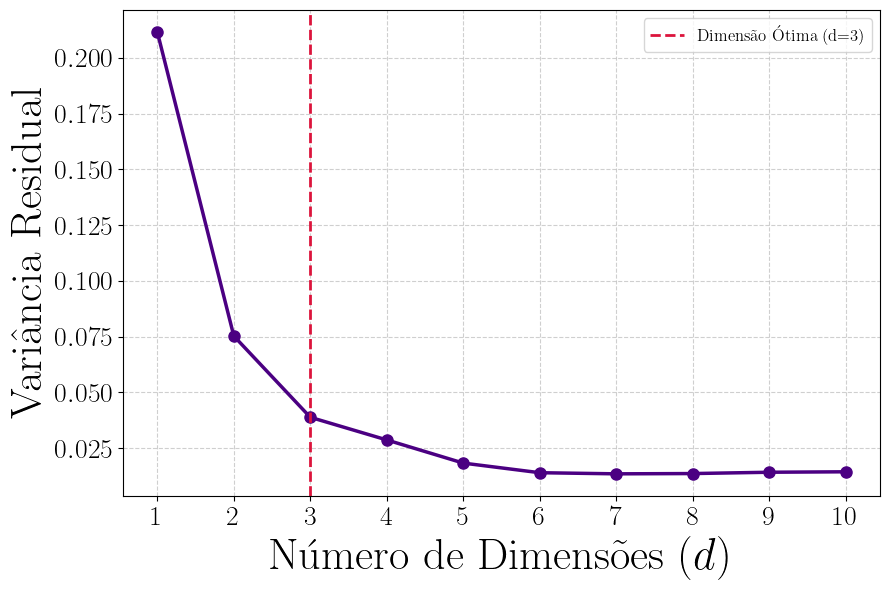

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

# =====================================================================
# 1. SIMULAÇÃO DOS DADOS (Substitua pela sua matriz do ProDy)
# =====================================================================
# Aqui simulamos uma matriz de correlação (N=370 resíduos da MBP)
N = 370
# Se você já tem a sua matriz de correlação do ProDy, carregue-a aqui:
# C = sua_matriz_de_correlacao_do_prody
C = np.load("Dados/matrizes/apo/1OMP_matriz.npy")
C = (C + C.T) / 2          # Garantir simetria
np.fill_diagonal(C, 1)     # A correlação de um resíduo com ele mesmo é 1

# =====================================================================
# 2. A TRANSIÇÃO MÉTRICA TOPOLÓGICA
# =====================================================================
# Conforme a Equação do artigo: D_ij = 1 - |C_ij|
D = 1 - np.abs(C)

# =====================================================================
# 3. PREPARANDO O ISOMAP PARA O TESTE DO COTOVELO
# =====================================================================
max_dims = 10  # Vamos testar de 1 até 10 dimensões
dimensions = range(1, max_dims + 1)
residual_variances = []

# n_neighbors define a "vizinhança" no grafo para o cálculo das geodésicas.
# Dica: No artigo, muitas vezes testa-se K entre 5 e 15.
k_vizinhos = 10 

print("Calculando o Gráfico Scree para o ISOMAP...")

for d in dimensions:
    # Configura o ISOMAP informando que D já é uma matriz de distâncias (precomputed)
    isomap = Isomap(n_neighbors=k_vizinhos, n_components=d, metric='precomputed')
    
    # Executa a projeção: Y é o conjunto de coordenadas de baixa dimensão
    Y = isomap.fit_transform(D)
    
    # D_G: Matriz de distâncias Geodésicas reais calculadas sobre o Grafo (N x N)
    D_G = isomap.dist_matrix_
    
    # D_Y: Nova matriz de distâncias Euclidianas no espaço reduzido Y (N x N)
    D_Y = squareform(pdist(Y, metric='euclidean'))
    
    # Para o R^2, precisamos analisar par a par.
    # Pegamos apenas o triângulo superior da matriz para não duplicar dados
    # e ignoramos a diagonal principal (que é zero).
    triu_indices = np.triu_indices_from(D_G, k=1)
    vec_DG = D_G[triu_indices]
    vec_DY = D_Y[triu_indices]
    
    # Calculamos o Coeficiente de Correlação de Pearson (R)
    r, _ = pearsonr(vec_DG, vec_DY)
    
    # Variância Residual = 1 - R^2 (A equação do seu texto em LaTeX)
    r_squared = r**2
    res_var = 1 - r_squared
    residual_variances.append(res_var)
    
    print(f"Dimensão: {d} | Variância Residual: {res_var:.4f}")

# =====================================================================
# 4. PLOTAGEM DO GRÁFICO SCREE
# =====================================================================
plt.figure(figsize=(9, 6))
plt.plot(dimensions, residual_variances, marker='o', linestyle='-', color='indigo', linewidth=2.5, markersize=8)

# plt.title('Gráfico Scree - ISOMAP', fontsize=40, fontweight='bold')
plt.xlabel('Número de Dimensões ($d$)', fontsize=32)
plt.ylabel('Variância Residual', fontsize=32)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(dimensions, fontsize=20)  # Aplica o tamanho 30 nos números do eixo X
plt.yticks(fontsize=20)  

# Destacar a dimensão d=3 (Onde o artigo diz que o cotovelo ocorre para a MBP)
plt.axvline(x=3, color='crimson', linestyle='--', label='Dimensão Ótima (d=3)', linewidth=2)

plt.legend(fontsize=12)
plt.tight_layout()

# Salva a imagem em alta qualidade para você colocar na sua monografia!
# plt.savefig("grafico_scree_isomap.png", dpi=300)
plt.show()